# **DSA 506 Project - Can AI Understand Human Emotion Through Music?**
## ***Submitted by: Shreyasee Poddar***
### **Research Question:** Can song data, including lyrics, audio features, and artist characteristics, help AI identify emotional patterns in modern music?

In [47]:
# Installing Libraries
!pip install textblob wordcloud plotly -q

In [49]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob
from wordcloud import WordCloud
import re
import warnings

warnings.filterwarnings("ignore")

In [50]:
# Uploading Dataset
from google.colab import files
uploaded = files.upload()

Saving spotify_songs.csv to spotify_songs.csv


In [52]:
# Loading Dataset
df = pd.read_csv("spotify_songs.csv")
df.head()

,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,language
0,0017A6SJgTbfQVU2EtsPNo,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,41,1srJQ0njEQgd8w4XSqI4JQ,Trip,2001-01-01,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,...,-10.068,1,0.0236,0.27900,0.01170,0.0887,0.566,97.091,235440,tl
1,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,Hard Rock Workout,3YouF0u7waJnolytf9JCXf,...,-4.739,1,0.0442,0.01170,0.00994,0.3470,0.404,135.225,373512,en
2,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,...,-7.504,0,0.2160,0.00432,0.00723,0.4890,0.650,111.904,262467,en
3,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,Christmas Soul,6FZYc2BvF7tColxO8PBShV,...,-5.819,0,0.0341,0.68900,0.00000,0.0664,0.405,118.593,243067,en
4,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,K-Party Dance Mix,37i9dQZF1DX4RDXswvP6Mj,...,-1.993,1,0.0409,0.03700,0.00000,0.1380,0.240,130.018,193160,en


In [53]:
# Checking Dataset
print("Rows and columns:", df.shape)
df.info()

Rows and columns: (18454, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18454 entries, 0 to 18453
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  18454 non-null  object 
 1   track_name                18454 non-null  object 
 2   track_artist              18454 non-null  object 
 3   lyrics                    18194 non-null  object 
 4   track_popularity          18454 non-null  int64  
 5   track_album_id            18454 non-null  object 
 6   track_album_name          18454 non-null  object 
 7   track_album_release_date  18454 non-null  object 
 8   playlist_name             18454 non-null  object 
 9   playlist_id               18454 non-null  object 
 10  playlist_genre            18454 non-null  object 
 11  playlist_subgenre         18454 non-null  object 
 12  danceability              18454 non-null  float64
 13  energy                    18454

In [54]:
df.isnull().sum()

,0
track_id,0
track_name,0
track_artist,0
lyrics,260
track_popularity,0
track_album_id,0
track_album_name,0
track_album_release_date,0
playlist_name,0
playlist_id,0


## **The Hook**

Music is one of the most emotional forms of human expression. People use music when they are happy, heartbroken, stressed, motivated, or nostalgic. But can these emotions be measured using data? This project explores whether AI can identify emotional patterns in music using lyrics, audio features, and artist characteristics.

In [55]:
# Basic Cleaning
df.columns = df.columns.str.lower().str.strip()

df = df.drop_duplicates(subset=["track_id"])
df = df.dropna(subset=["track_name", "track_artist", "lyrics", "playlist_genre"])

df["track_album_release_date"] = pd.to_datetime(df["track_album_release_date"], errors="coerce")
df["year"] = df["track_album_release_date"].dt.year

df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

df.head()

,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,language,year
0,0017A6SJgTbfQVU2EtsPNo,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,41,1srJQ0njEQgd8w4XSqI4JQ,Trip,2001-01-01,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,...,1,0.0236,0.27900,0.01170,0.0887,0.566,97.091,235440,tl,2001
1,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,Hard Rock Workout,3YouF0u7waJnolytf9JCXf,...,1,0.0442,0.01170,0.00994,0.3470,0.404,135.225,373512,en,2017
2,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,...,0,0.2160,0.00432,0.00723,0.4890,0.650,111.904,262467,en,2005
3,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,Christmas Soul,6FZYc2BvF7tColxO8PBShV,...,0,0.0341,0.68900,0.00000,0.0664,0.405,118.593,243067,en,2012
4,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,K-Party Dance Mix,37i9dQZF1DX4RDXswvP6Mj,...,1,0.0409,0.03700,0.00000,0.1380,0.240,130.018,193160,en,2019


In [56]:
# Keeping English Songs Only
df = df[df["language"] == "en"].copy()

print("Dataset after filtering English songs:", df.shape)
df[["track_name", "track_artist", "playlist_genre", "lyrics"]].head()

Dataset after filtering English songs: (14200, 26)


,track_name,track_artist,playlist_genre,lyrics
1,I Feel Alive,Steady Rollin,rock,"The trees, are singing in the wind The sky blu..."
2,Poison,Bell Biv DeVoe,r&b,"NA Yeah, Spyderman and Freeze in full effect U..."
3,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,r&b,I really can't stay Baby it's cold outside I'v...
4,Dumb Litty,KARD,pop,Get up out of my business You don't keep me fr...
5,Soldier,James TW,r&b,"Hold your breath, don't look down, keep trying..."


## **The Context**

This dataset contains Spotify songs with audio features, lyrics, artist names, genres, popularity scores, and release years. The project uses three major data types: numerical data such as energy and valence, categorical data such as genre and artist, and text data from lyrics.

In [57]:
# Selecting Main Features
audio_features = [
    "track_popularity", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

category_features = [
    "track_artist", "playlist_genre", "playlist_subgenre", "year"
]

text_feature = "lyrics"

df[audio_features].describe().round(3)

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,14200.000,14200.000,14200.000,14200.000,14200.000,14200.000,14200.000,14200.000,14200.000,14200.000,14200.000
mean,42.235,0.634,0.690,-6.760,0.104,0.167,0.045,0.189,0.503,120.803,231100.440
std,24.648,0.150,0.183,2.895,0.101,0.218,0.151,0.151,0.226,27.133,56745.886
min,0.000,0.116,0.017,-34.283,0.022,0.000,0.000,0.009,0.000,37.114,31893.000
25%,24.000,0.537,0.566,-8.256,0.039,0.013,0.000,0.093,0.331,99.989,194207.750
50%,47.000,0.647,0.712,-6.237,0.058,0.070,0.000,0.129,0.502,120.074,222111.000
75%,62.000,0.744,0.835,-4.707,0.124,0.234,0.002,0.246,0.677,135.448,258747.750
max,100.000,0.979,1.000,1.275,0.918,0.992,0.974,0.996,0.991,212.137,517125.000


## **Methodology**

The methodology followed five steps. First, the dataset was cleaned by removing duplicate tracks, missing lyrics, and non-English songs. Second, audio features were used as numerical variables to measure energy, valence, danceability, loudness, tempo, and popularity. Third, artist and genre were used as categorical variables. Fourth, lyrics were cleaned and analyzed using sentiment analysis. Finally, visualizations and animation were used to communicate the emotional patterns in a story format.

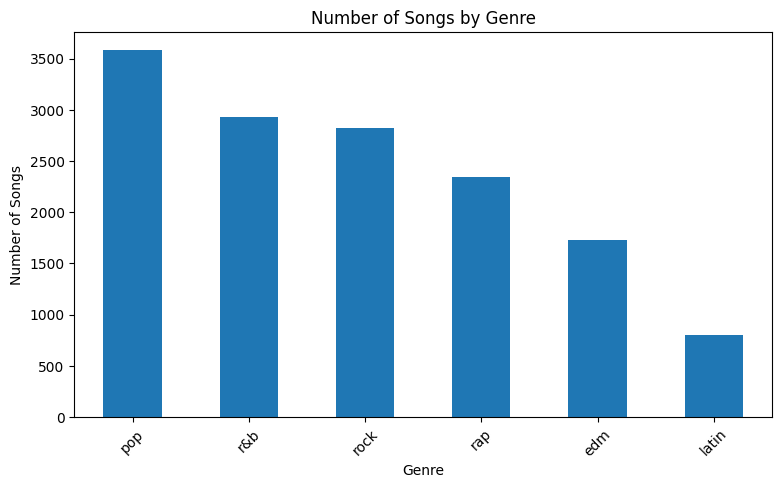

In [60]:
# Genre Distribution Plot
genre_counts = df["playlist_genre"].value_counts()

plt.figure(figsize=(9,5))
genre_counts.plot(kind="bar")
plt.title("Number of Songs by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

### Interpretation:
The above barchart shows that the dataset contains six major playlist genres: EDM, Latin, Pop, R&B, Rap, and Rock. This gives the project a balanced musical landscape for comparing emotional patterns across different styles. Since the genres represent different listening contexts, they provide a strong foundation for analyzing how emotion changes across music categories.

## **AI-Based Emotion Labeling**

In this project, AI emotion detection is represented through rule-based mood classification and lyric sentiment analysis. Energy and valence are used to assign songs into emotional categories, while TextBlob sentiment analysis estimates the emotional tone of lyrics.

In [61]:
# Creating Mood Categories
def classify_mood(row):
    if row["energy"] >= 0.6 and row["valence"] >= 0.6:
        return "Happy / Energetic"
    elif row["energy"] >= 0.6 and row["valence"] < 0.6:
        return "Intense / Dark"
    elif row["energy"] < 0.6 and row["valence"] >= 0.6:
        return "Calm / Positive"
    else:
        return "Sad / Calm"

df["mood_category"] = df.apply(classify_mood, axis=1)

df["mood_category"].value_counts()

,count
mood_category,
Intense / Dark,6027
Happy / Energetic,3927
Sad / Calm,3195
Calm / Positive,1051


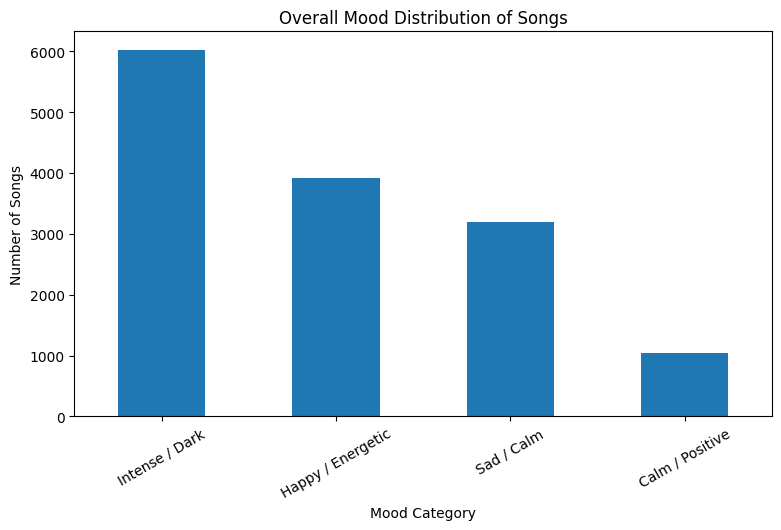

In [62]:
# Mood Distribution Plot
mood_counts = df["mood_category"].value_counts()

plt.figure(figsize=(9,5))
mood_counts.plot(kind="bar")
plt.title("Overall Mood Distribution of Songs")
plt.xlabel("Mood Category")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)
plt.show()

### Interpretation:
From the above barchart, we can see the most common mood category is Intense / Dark, followed by Happy / Energetic and Sad / Calm. This suggests that many songs in the dataset have high energy but lower positivity. This is important because it shows that energetic music is not always emotionally happy; some songs can feel powerful, aggressive, or emotionally intense.

## **The Conflict**

The main challenge is that emotion is subjective. A song can sound energetic but still feel emotionally dark. Another song can have sad lyrics but remain popular and danceable. This creates a conflict for AI: it can detect patterns in data, but understanding human emotion still requires interpretation.

In [63]:
# Emotional Music Map
fig = px.scatter(
    df.sample(3000, random_state=42),
    x="valence",
    y="energy",
    color="mood_category",
    size="track_popularity",
    hover_data=["track_name", "track_artist", "playlist_genre"],
    title="Emotional Music Map: Energy vs Valence",
    opacity=0.7
)

fig.show()

### Interpretation:
The above emotional music map shows that songs are spread across different emotional zones. Songs with high energy and high valence appear as Happy / Energetic, while songs with high energy but lower valence fall into the Intense / Dark group. This supports the main research question because audio features can help AI separate songs into emotional patterns.

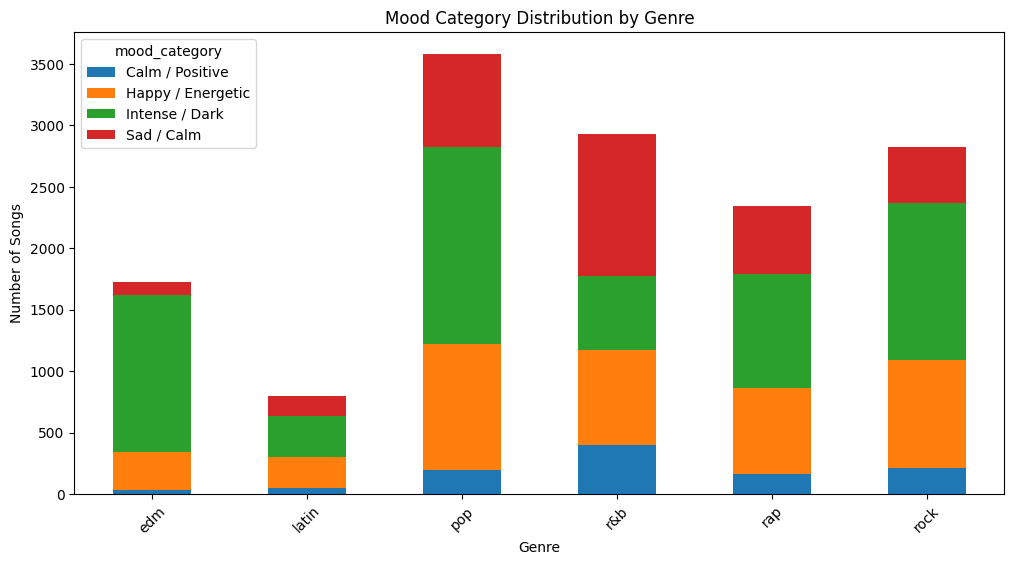

In [64]:
# Genre vs Mood
genre_mood = pd.crosstab(df["playlist_genre"], df["mood_category"])

genre_mood.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Mood Category Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

### Interpretation:
The above stacked bar chart shows that genres have different emotional profiles. Some genres contain a larger share of intense and energetic songs, while others include more calm or positive songs. This means that genre is not only a music label; it also carries emotional information that can help explain how listeners experience songs.

In [65]:
# Average Audio Features by Genre
genre_summary = df.groupby("playlist_genre")[["energy", "valence", "danceability", "track_popularity"]].mean().round(3)
genre_summary

,energy,valence,danceability,track_popularity
playlist_genre,,,,
edm,0.802,0.409,0.636,33.639
latin,0.683,0.520,0.678,43.001
pop,0.695,0.504,0.637,48.908
r&b,0.579,0.527,0.666,39.070
rap,0.680,0.506,0.720,41.801
rock,0.738,0.530,0.515,42.461


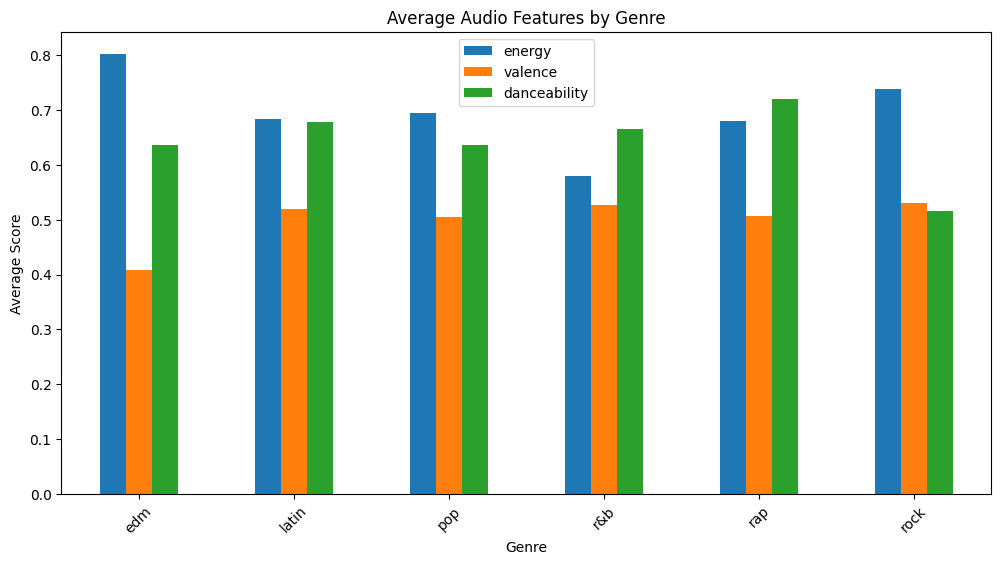

In [66]:
genre_summary[["energy", "valence", "danceability"]].plot(kind="bar", figsize=(12,6))
plt.title("Average Audio Features by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

### Interpretation:
The average feature comparison shows that genres have different musical identities. EDM has very high energy, while rap and Latin show strong danceability. R&B appears smoother with relatively lower energy. These differences show that each genre carries a measurable emotional and musical profile.

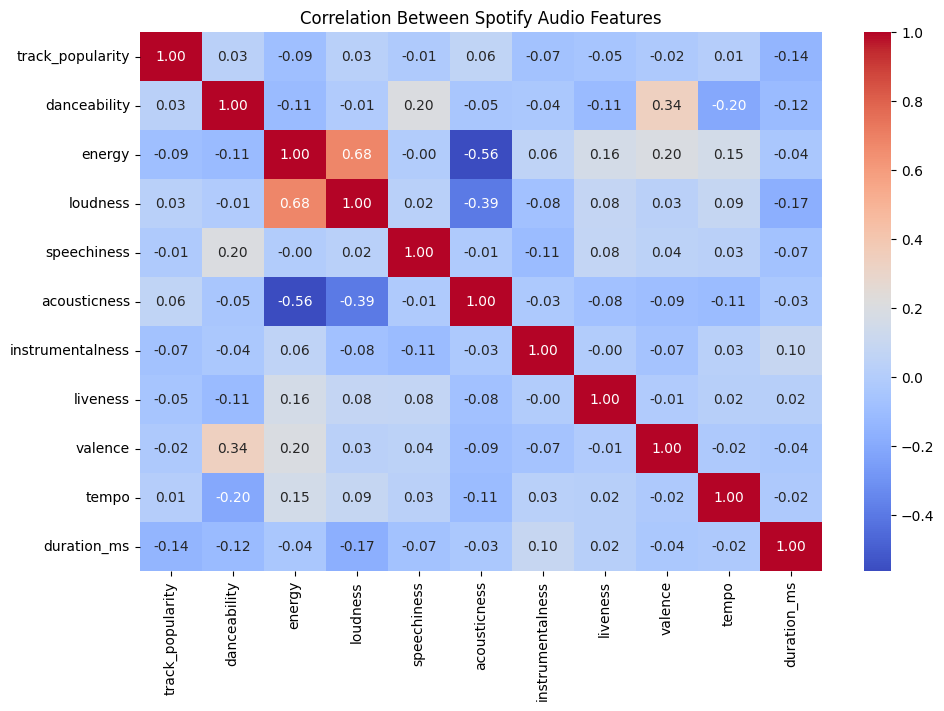

In [67]:
# Correlation Heatmap
plt.figure(figsize=(11,7))
sns.heatmap(df[audio_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Spotify Audio Features")
plt.show()

### Interpretation:
The above correlation heatmap shows that energy and loudness are strongly related, which means louder songs often feel more intense. Acousticness tends to move in the opposite direction from high-energy production features. This supports the idea that emotional patterns in music are not random; they are connected to measurable audio characteristics.

## **The Journey**

The analysis started by cleaning the dataset and filtering English songs. Then numerical audio features were analyzed to measure energy, positivity, danceability, tempo, and popularity. Categorical variables such as genre and subgenre were used to compare musical groups. Finally, lyrics were analyzed using text sentiment to add a human emotional layer to the project.

In [68]:
# Cleaning Lyrics
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_lyrics"] = df["lyrics"].apply(clean_text)

df[["track_name", "track_artist", "clean_lyrics"]].head()

,track_name,track_artist,clean_lyrics
1,I Feel Alive,Steady Rollin,the trees are singing in the wind the sky blue...
2,Poison,Bell Biv DeVoe,na yeah spyderman and freeze in full effect uh...
3,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,i really can t stay baby it s cold outside i v...
4,Dumb Litty,KARD,get up out of my business you don t keep me fr...
5,Soldier,James TW,hold your breath don t look down keep trying d...


In [69]:
# Lyrics Sentiment
df["lyric_sentiment"] = df["clean_lyrics"].apply(lambda x: TextBlob(x).sentiment.polarity)

df[["track_name", "track_artist", "playlist_genre", "lyric_sentiment"]].head()

,track_name,track_artist,playlist_genre,lyric_sentiment
1,I Feel Alive,Steady Rollin,rock,0.211458
2,Poison,Bell Biv DeVoe,r&b,0.115242
3,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,r&b,0.113423
4,Dumb Litty,KARD,pop,-0.442188
5,Soldier,James TW,r&b,0.232474


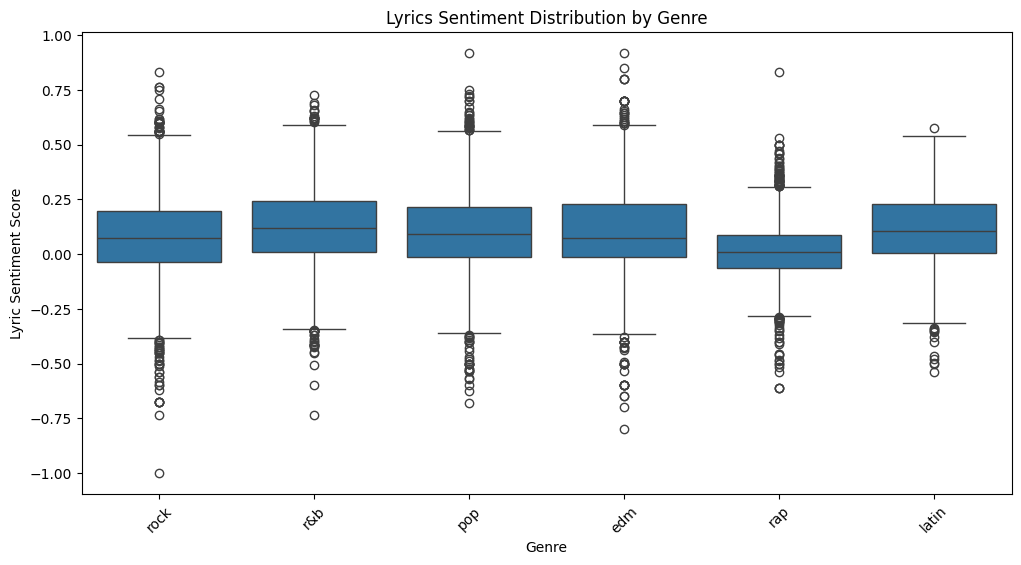

In [70]:
# Sentiment by Genre
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="playlist_genre", y="lyric_sentiment")
plt.title("Lyrics Sentiment Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Lyric Sentiment Score")
plt.xticks(rotation=45)
plt.show()

### Interpretation:
The lyric sentiment distribution shows that most genres are centered close to neutral sentiment, but there is still variation across songs. This means lyrics alone may not fully explain musical emotion. For stronger emotion detection, AI needs both text-based sentiment and audio features such as energy, valence, and danceability.

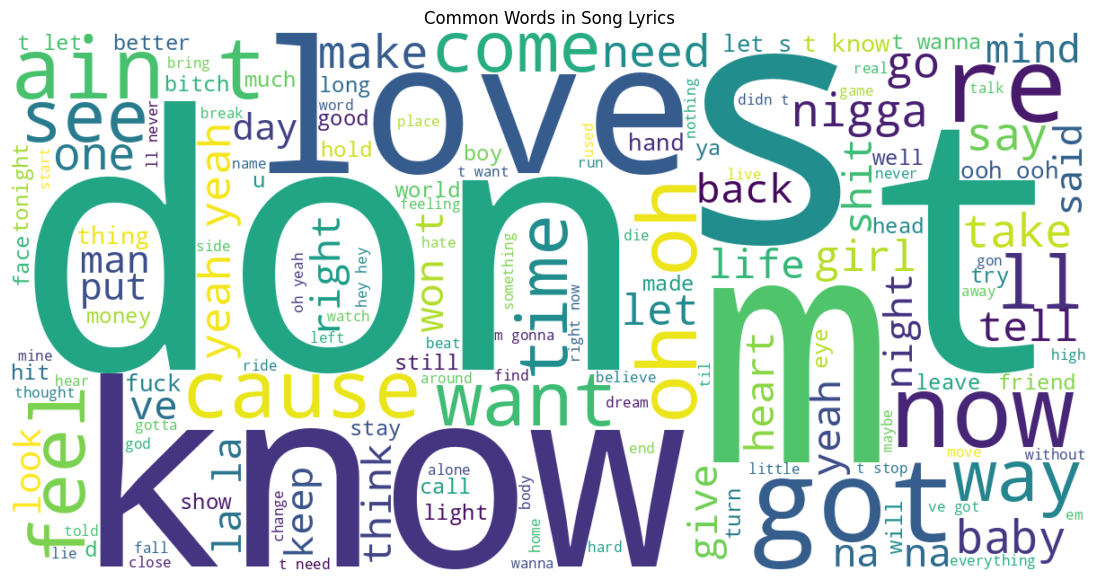

In [71]:
# Word Cloud
sample_text = " ".join(df["clean_lyrics"].sample(5000, random_state=42))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(sample_text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Song Lyrics")
plt.show()

### Interpretation:
The above word cloud highlights common words used across song lyrics. These repeated words make the project more human-centered because they show the themes and language that appear in music. While audio features measure sound, lyrics provide emotional context and help connect the analysis to real human experience.

In [72]:
# Top Artists for Comparison
top_artists = df["track_artist"].value_counts().head(10).index

df_top_artists = df[df["track_artist"].isin(top_artists)].copy()

df_top_artists["track_artist"].value_counts()

,count
track_artist,
Queen,120
David Guetta,70
Drake,65
Logic,63
Guns N' Roses,62
The Chainsmokers,59
Martin Garrix,52
2Pac,51
The Weeknd,49


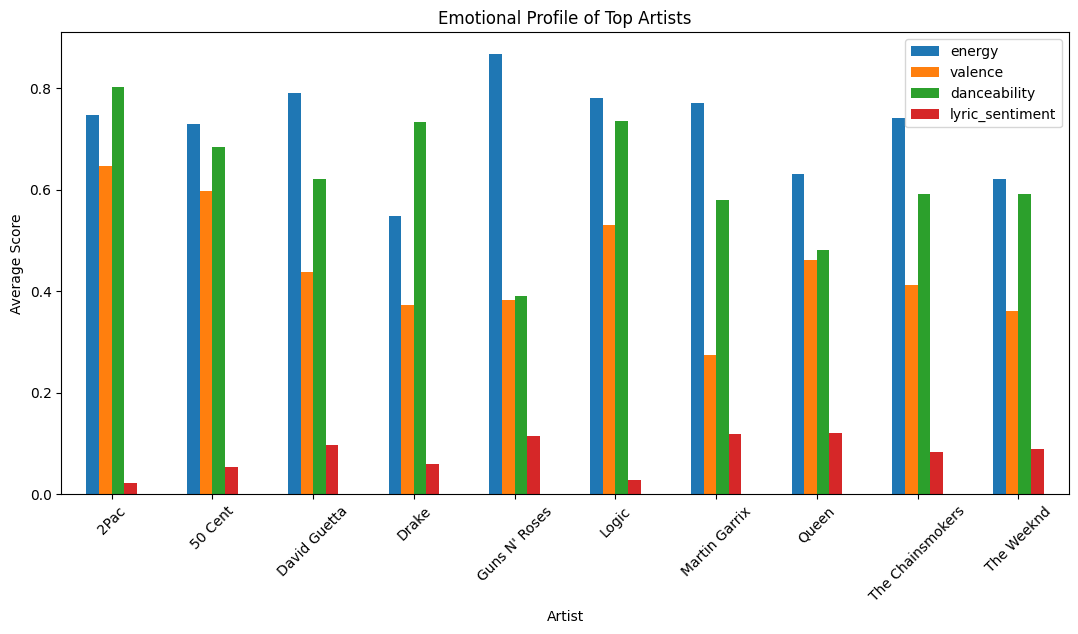

In [73]:
# Artist Emotional Profile
artist_summary = df_top_artists.groupby("track_artist")[["energy", "valence", "danceability", "lyric_sentiment"]].mean().round(3)

artist_summary.plot(kind="bar", figsize=(13,6))
plt.title("Emotional Profile of Top Artists")
plt.xlabel("Artist")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

### Interpretation:
The artist comparison shows that each top artist has a different emotional fingerprint. Some artists have higher energy or danceability, while others show stronger lyrical sentiment. This supports the idea that AI can use artist characteristics, lyrics, and audio features together to identify emotional patterns in music.

In [74]:
# Animated bubble chart
df_anim = df.dropna(subset=["year", "energy", "valence", "track_popularity"]).copy()
df_anim = df_anim[(df_anim["year"] >= 2000) & (df_anim["year"] <= 2020)]

df_anim_sample = df_anim.sample(min(4000, len(df_anim)), random_state=42)

fig = px.scatter(
    df_anim_sample,
    x="valence",
    y="energy",
    animation_frame="year",
    color="playlist_genre",
    size="track_popularity",
    hover_name="track_name",
    hover_data=["track_artist", "mood_category"],
    range_x=[0, 1],
    range_y=[0, 1],
    title="Animated Emotional Music Map Over Time"
)

fig.show()

### Interpretation:
The above animated bubble chart shows how songs appear in emotional space across release years. Each bubble represents a song, with position based on valence and energy, color based on genre, and size based on popularity. This animation is useful because it shows that musical emotion can be explored dynamically over time instead of only through static charts.

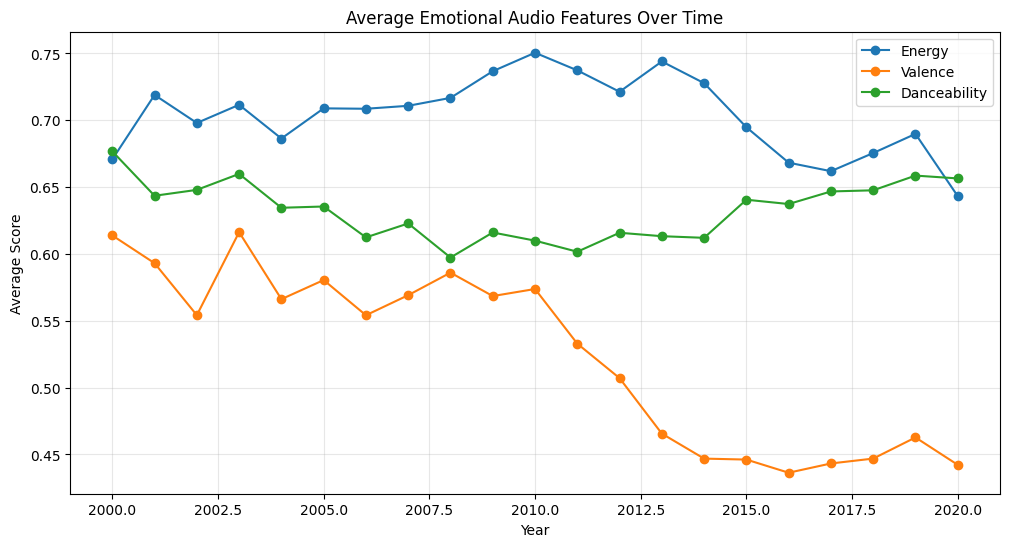

In [75]:
# Time-series Plot
yearly_mood = df_anim.groupby("year")[["energy", "valence", "danceability", "track_popularity"]].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(yearly_mood["year"], yearly_mood["energy"], marker="o", label="Energy")
plt.plot(yearly_mood["year"], yearly_mood["valence"], marker="o", label="Valence")
plt.plot(yearly_mood["year"], yearly_mood["danceability"], marker="o", label="Danceability")

plt.title("Average Emotional Audio Features Over Time")
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation:
This above time-series chart shows that average energy remains relatively high across most years, while valence gradually decreases after the early 2010s. This suggests that songs in later years may still sound energetic, but their emotional tone becomes less positive on average. Danceability remains fairly stable, which shows that modern songs continue to maintain a strong rhythmic structure.


In [77]:
# Animated Time-Series Trend
yearly_mood_long = yearly_mood.melt(
    id_vars="year",
    value_vars=["energy", "valence", "danceability"],
    var_name="Audio Feature",
    value_name="Average Score"
)
frames = []

for frame_year in sorted(yearly_mood_long["year"].unique()):
    temp = yearly_mood_long[yearly_mood_long["year"] <= frame_year].copy()
    temp["frame_year"] = frame_year
    frames.append(temp)

yearly_mood_cumulative = pd.concat(frames)

fig = px.line(
    yearly_mood_cumulative,
    x="year",
    y="Average Score",
    color="Audio Feature",
    animation_frame="frame_year",
    range_x=[yearly_mood["year"].min(), yearly_mood["year"].max()],
    range_y=[0, 1],
    title="Animated Time-Series: Emotional Audio Features Over Time",
    markers=True
)

fig.show()

### Interpretation:
The above animated time-series chart shows how the overall emotional profile of songs develops over time. Unlike the bubble animation, this chart summarizes yearly averages. It shows that energy stays relatively high, danceability remains stable, and valence decreases after the early 2010s, suggesting that songs may have become less positive in emotional tone while still remaining energetic and rhythmic.

## **The Resolution**

The analysis shows that AI can identify emotional patterns in music by combining audio features, lyrics, and artist or genre categories. Energy and valence help create mood categories, while lyrics sentiment adds another emotional layer. However, AI does not fully understand emotion the way humans do. It detects measurable signals, but human interpretation is still needed.

## **The Call to Action**

Streaming platforms, playlist creators, and music marketers can use emotion-based music analysis to improve recommendations. Instead of recommending songs only by genre or popularity, platforms can recommend songs based on emotional needs such as motivation, relaxation, nostalgia, or mood recovery.

## **The Emotional Appeal**

Music is not just data. It is connected to memory, identity, heartbreak, motivation, and healing. Behind every song is a human feeling. This project shows how data can help us understand emotion, while also reminding us that music remains deeply personal.

## **Final Conclusion**

This project analyzed modern music using numerical audio features, categorical artist and genre information, and text-based lyric sentiment. The results show that AI can detect emotional patterns in songs, especially through energy, valence, danceability, and sentiment. The strongest insight is that music emotion is measurable but not completely explainable by data alone.

In [78]:
# Exporting Tableau Dataset
tableau_cols = [
    "track_id", "track_name", "track_artist", "playlist_genre",
    "playlist_subgenre", "year", "track_popularity",
    "danceability", "energy", "valence", "tempo", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "duration_ms", "mood_category", "lyric_sentiment", "language"
]

tableau_df = df[tableau_cols].copy()

tableau_df.to_csv("tableau_music_emotion_dataset.csv", index=False)

files.download("tableau_music_emotion_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
# Saving Clean Notebook Dataset Also
df.to_csv("cleaned_music_emotion_dataset.csv", index=False)
files.download("cleaned_music_emotion_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>